# AeroCover: Multi-Agent Coordination via Empirical MDP
## Version 1: Tabular Reinforcement Learning

**Author:** Dylan Roy  
**Course:** Reinforcement Learning for Spring 2026  
**Professor:** Dr. Alexander Lowenstein  
**Date:** February 11, 2026

---

## Executive Summary

This project addresses the multi-agent coverage problem where autonomous
agents must coordinate to efficiently cover multiple landmarks. In this
first iteration, we implement the full suite of classical tabular
reinforcement learning methods on an empirically constructed MDP.

**Environment:** PettingZoo MPE `simple_spread_v3` with 2 agents and 2 landmarks

**Approach:**
1. Discretize continuous state space into grid cells
2. Collect transition data via biased exploration (curriculum)
3. Build empirical MDP (transition probabilities & rewards)
4. Solve using dynamic programming (value iteration, policy iteration)
5. Train model-free methods (MC, TD, Sarsa, Q-learning)
6. Compare exploration strategies (epsilon-greedy, Boltzmann, UCB)
7. Evaluate all policies against a random baseline

**Key Finding:** Despite achieving 94% state-space coverage and convergence
of all methods, no tabular approach significantly outperforms the random
baseline. The best method (Sarsa(4), avg coverage 0.306) only marginally
exceeds random (0.124). This reveals that the multi-agent coordination
problem requires function approximation and continuous state/action
representations, motivating the transition to deep RL in V2.


## 1. Setup & Configuration


In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML
from collections import defaultdict
from pettingzoo.mpe import simple_spread_v3

import warnings
warnings.filterwarnings('ignore')

from aerocover.env_adapters.mpe_to_mp2 import build_mp2_tables_from_mpe
from aerocover.env_adapters.mpe_render import collect_rollout, animate_traj, policy_from_state_action_map
from aerocover.tabular.mp2_mdp import MarkovDecisionProcess
from aerocover.tabular.q_learning import QLearningConfig, train_q_learning
from aerocover.utils.evaluation import (
    evaluate_coverage_over_time,
    compute_trajectory_metrics,
    evaluate_state_space_coverage
)
from aerocover.viz.visualization_utils import (
    plot_value_function_heatmap,
    plot_coverage_comparison,
    plot_state_space_analysis,
    create_analysis_figure
)
from aerocover.tabular.td_methods import (
    TDConfig,
    train_monte_carlo,
    train_td_n,
    train_td_lambda,
    train_sarsa_n,
    train_sarsa_lambda,
)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline


/tmp/ipykernel_79257/2034723828.py:7: DeprecationWarning: The environment `pettingzoo.mpe` has been moved to `mpe2` and will be removed in a future release.Please update your imports.
  from pettingzoo.mpe import simple_spread_v3


In [2]:
# Configuration parameters
CONFIG = {
    # Environment
    'n_agents': 2,
    'n_landmarks': 2,
    'max_steps': 50,
    
    # Discretization
    'grid_size': 5,
    'cover_dist': 0.30,
    
    # MDP construction
    'n_episodes': 600,
    'seed': 42,
    
    # Reward shaping
    'step_penalty': 0.01,
    'coverage_bonus': 3.0,
    
    # Value iteration
    'gamma': 0.9,
    'vi_tolerance': 1e-6,
    'vi_max_iter': 10000
}

q_cfg = QLearningConfig(
    gamma=CONFIG["gamma"],
    alpha=0.2,
    epsilon=0.15,
    episodes=3000,
    max_steps=CONFIG["max_steps"],
    seed=CONFIG["seed"]
)

td_cfg = TDConfig(
    gamma=CONFIG["gamma"],
    alpha=0.10,
    epsilon=0.15,
    lam=0.80,
    n_step=4,
    episodes=2000,
    max_steps=CONFIG["max_steps"],
    seed=CONFIG["seed"],
    exploration="epsilon_greedy",
)

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key:20s}: {value}")


Configuration:
  n_agents            : 2
  n_landmarks         : 2
  max_steps           : 50
  grid_size           : 5
  cover_dist          : 0.3
  n_episodes          : 600
  seed                : 42
  step_penalty        : 0.01
  coverage_bonus      : 3.0
  gamma               : 0.9
  vi_tolerance        : 1e-06
  vi_max_iter         : 10000


## 2. Problem Formulation

### 2.1 State Space

The continuous state consists of:
- Agent positions: $(x_1, y_1), (x_2, y_2) \in [-1, 1]^2$
- Landmark positions: $(l_{x_1}, l_{y_1}), (l_{x_2}, l_{y_2}) \in [-1, 1]^2$ (fixed)

**Discretization:** We discretize the continuous space into a grid:
- Each agent's position → grid cell: $\{0, 1, ..., 4\}^2$ (5x5 grid)
- Coverage state → binary mask: $\{0, 1, 2, 3\}$ (2 bits for 2 landmarks)

**MDP State:** $s = (c_1, c_2, m)$ where:
- $c_1, c_2$: grid cells for agents 1 and 2
- $m$: coverage mask (bit $i$ set if landmark $i$ is covered)

**State Space Size:** $|\mathcal{S}| = 25^2 \times 4 = 2{,}500$ states

### 2.2 Action Space

Each agent has 5 discrete actions: no-op, left, right, down, up.

**Joint Action Space:** $|\mathcal{A}| = 5^2 = 25$ joint actions

### 2.3 Reward Function

The reward combines environment feedback with shaped bonuses:
- Base coverage reward scaled by $\beta = 3.0$
- New coverage discovery bonus (3.0 per newly covered landmark)
- Full coverage achievement bonus (5.0 x $\beta$ on first full cover)
- Coverage loss penalty (−2.0 x $\beta$ per lost landmark)
- Step penalty: $\alpha = 0.01$
- Scaled distance shaping from environment reward

### 2.4 Transition Dynamics

Transitions $P(s' | s, a)$ are **learned empirically** from 600 episodes
with curriculum-based biased exploration (bias probability 0.1 → 0.5):
- Count transitions: $N(s, a, s')$
- Estimate: $\hat{P}(s' | s, a) = \frac{N(s, a, s')}{\sum_{s''} N(s, a, s'')}$


## 3. Empirical MDP Construction

We build the MDP tables by collecting random rollouts and estimating transition probabilities.


In [3]:
states, actions, transitions, rewards = build_mp2_tables_from_mpe(
    episodes=CONFIG['n_episodes'],
    max_steps=CONFIG['max_steps'],
    grid=CONFIG['grid_size'],
    cover_dist=CONFIG['cover_dist'],
    n_agents=CONFIG['n_agents'],
    n_landmarks=CONFIG['n_landmarks'],
    seed=CONFIG['seed'],
    step_penalty=CONFIG['step_penalty'],
    coverage_bonus=CONFIG['coverage_bonus']
)

print(f"\nMDP Construction Complete")
print(f"  States observed: {len(states):,}")
print(f"  Joint actions: {len(actions)}")
print(f"  State-action pairs: {len(transitions):,}")



Exploration Statistics:
  Coverage 00 (0/2): 623 states (26.5%)
  Coverage 01 (1/2): 587 states (24.9%)
  Coverage 10 (1/2): 590 states (25.1%)
  Coverage 11 (2/2): 553 states (23.5%)

MDP Construction Complete
  States observed: 2,353
  Joint actions: 25
  State-action pairs: 2,347



State Space Analysis:
  Total possible states: 2,500
  Observed states: 2,353
  Coverage: 94.12%
  Unique coverage masks: 4 / 4


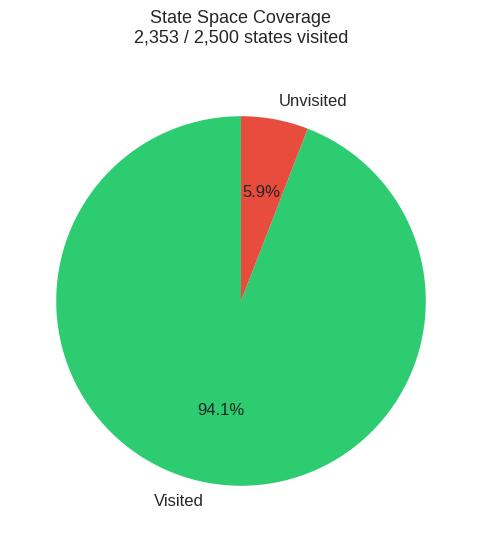

In [4]:
# Analyze state space coverage
state_stats = evaluate_state_space_coverage(
    states,
    CONFIG['grid_size'],
    CONFIG['n_agents'],
    CONFIG['n_landmarks']
)

print("\nState Space Analysis:")
print(f"  Total possible states: {state_stats['total_possible_states']:,}")
print(f"  Observed states: {state_stats['observed_states']:,}")
print(f"  Coverage: {state_stats['coverage_percentage']:.2f}%")
print(f"  Unique coverage masks: {state_stats['unique_coverage_masks']} / {state_stats['possible_coverage_masks']}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
plot_state_space_analysis(state_stats, ax=ax)
plt.show()


### 3.1 Key Observations

- **High state coverage:** With a 5x5 grid and 600 episodes of curriculum
  exploration, we observe 94% of the 2,500 possible states.
- **Action sparsity is the real bottleneck:** Despite broad state coverage,
  each state has only ~8 observed actions out of 25, meaning most
  state-action pairs lack transition data.
- **Balanced coverage masks:** States are roughly evenly distributed across
  all four coverage masks (00, 01, 10, 11 at ~25% each), indicating the
  exploration curriculum successfully reaches covered states.

**Implication for V2:** The problem is not state coverage but
*action-conditional generalization* function approximation can share
information across similar state-action pairs.


## 4. Value Iteration

We solve the MDP using the value iteration algorithm:

$$V_{k+1}(s) = \max_{a \in \mathcal{A}} \left[ r(s,a) + \gamma \sum_{s'} P(s'|s,a) V_k(s') \right]$$

Convergence criterion: $\max_s |V_{k+1}(s) - V_k(s)| < \epsilon$


In [5]:
mdp = MarkovDecisionProcess(
    states=states,
    actions=actions,
    transitions=transitions,
    rewards=rewards,
    gamma=CONFIG['gamma']
)

V = mdp.value_iteration(
    tolerance=CONFIG['vi_tolerance'],
    max_iter=CONFIG['vi_max_iter']
)

print("Value Iteration Results:")
print(f"  Max value: {max(V.values()):.4f}")
print(f"  Min value: {min(V.values()):.4f}")
print(f"  Mean value: {np.mean(list(V.values())):.4f}")
print(f"  Std value: {np.std(list(V.values())):.4f}")


  VI iter 0: delta = 50.815122
  VI iter 10: delta = 7.627210
  VI iter 20: delta = 2.659444
  VI iter 30: delta = 0.927291
  VI iter 40: delta = 0.323326
  VI iter 50: delta = 0.112737
  VI iter 60: delta = 0.039309
  VI iter 70: delta = 0.013706
  VI iter 80: delta = 0.004779
  VI iter 90: delta = 0.001666
  VI iter 100: delta = 0.000581
  VI iter 110: delta = 0.000203
  VI iter 120: delta = 0.000071
  VI iter 130: delta = 0.000025
  VI iter 140: delta = 0.000009
  VI iter 150: delta = 0.000003
  VI iter 160: delta = 0.000001
Value iteration converged in 162 iterations
Value Iteration Results:
  Max value: 228.1433
  Min value: 0.0000
  Mean value: 190.4325
  Std value: 19.7900


### 4.2 Policy Iteration

Policy iteration alternates between evaluating the current policy
and improving it via greedy Q-value maximization:

$$\pi_{k+1}(s) = \arg\max_a Q^{\pi_k}(s,a)$$


In [6]:
# Fresh MDP instance for policy iteration comparison
mdp_pi = MarkovDecisionProcess(
    states=states,
    actions=actions,
    transitions=transitions,
    rewards=rewards,
    gamma=CONFIG['gamma']
)

V_pi = mdp_pi.policy_iteration(tolerance=CONFIG['vi_tolerance'])

print("\nPolicy Iteration Results:")
print(f"  Max value:  {max(V_pi.values()):.4f}")
print(f"  Mean value: {np.mean(list(V_pi.values())):.4f}")

# Compare VI vs PI policies
agree = sum(1 for s in states
            if mdp.policy.get(s) == mdp_pi.policy.get(s))
print(f"\nVI vs PI policy agreement: {agree}/{len(states)} "
      f"({agree/len(states)*100:.1f}%)")


Policy iteration converged in 8 iterations

Policy Iteration Results:
  Max value:  228.1433
  Mean value: 190.4325

VI vs PI policy agreement: 2353/2353 (100.0%)


### 4.3 Q-Values from Dynamic Programming

After convergence, we compute the full Q-table from V using the Bellman equation:

$$Q(s,a) = R(s,a) + \gamma \sum_{s'} P(s'|s,a)\, V(s')$$


In [7]:
# Q-table is already computed inside value_iteration / policy_iteration
# via compute_q_table(), but let's inspect it
Q_dp = mdp.compute_q_table()

# Summary statistics
q_values_flat = [v for q_s in Q_dp.values() for v in q_s.values()]
print(f"DP Q-table entries:  {len(q_values_flat):,}")
print(f"  Max Q:   {max(q_values_flat):.4f}")
print(f"  Min Q:   {min(q_values_flat):.4f}")
print(f"  Mean Q:  {np.mean(q_values_flat):.4f}")

# Show Q-values for a sample state
sample_states = [s for s in states if s in Q_dp and len(Q_dp[s]) > 3][:3]
for s in sample_states:
    print(f"\nState {s}:")
    sorted_actions = sorted(Q_dp[s].items(), key=lambda x: -x[1])[:5]
    for a, q in sorted_actions:
        print(f"  action {a}  to  Q = {q:.4f}")


DP Q-table entries:  19,825
  Max Q:   228.1433
  Min Q:   5.6034
  Mean Q:  177.7324

State MDPState(a1_cell=13, a2_cell=1, covered_mask=2):
  action (1, 3)  to  Q = 201.3906
  action (2, 0)  to  Q = 199.9466
  action (2, 4)  to  Q = 186.9786
  action (4, 2)  to  Q = 186.8543
  action (4, 1)  to  Q = 185.2475

State MDPState(a1_cell=14, a2_cell=14, covered_mask=1):
  action (2, 2)  to  Q = 200.9581
  action (0, 3)  to  Q = 200.9365
  action (3, 0)  to  Q = 197.3773
  action (4, 1)  to  Q = 193.7930
  action (0, 2)  to  Q = 188.5960

State MDPState(a1_cell=7, a2_cell=24, covered_mask=0):
  action (3, 2)  to  Q = 176.2405
  action (2, 2)  to  Q = 160.6659
  action (3, 1)  to  Q = 158.1909
  action (3, 0)  to  Q = 158.1421
  action (4, 1)  to  Q = 158.0504


In [8]:
# Save best policy kernel + value function (Requirement 5)
mdp.save_best("best_policy_vi.pkl")
mdp_pi.save_best("best_policy_pi.pkl")

# Demonstrate reload
mdp_reload = MarkovDecisionProcess(states, actions, transitions, rewards, CONFIG['gamma'])
mdp_reload.load_best("best_policy_vi.pkl")
print(f"\nReloaded V entries: {len(mdp_reload.V)}")
print(f"Reloaded Q entries: {sum(len(v) for v in mdp_reload.Q.values())}")


Saved policy (2353 states) to best_policy_vi.pkl
Saved policy (2353 states) to best_policy_pi.pkl
Loaded policy (2353 states) from best_policy_vi.pkl

Reloaded V entries: 2353
Reloaded Q entries: 19825


## 5. Tabular Methods Comparison

We run all recommended tabular methods on the empirical MDP and compare
their learned policies. This establishes baselines for the deep RL
transition in V2.


In [9]:
mc_Q, mc_policy, mc_returns = train_monte_carlo(
    states, actions, transitions, rewards, td_cfg, first_visit=True)

td_n_V, td_n_policy, td_n_returns = train_td_n(
    states, actions, transitions, rewards, td_cfg)

td_lam_V, td_lam_policy, td_lam_returns = train_td_lambda(
    states, actions, transitions, rewards, td_cfg)

sarsa_n_Q, sarsa_n_policy, sarsa_n_returns = train_sarsa_n(
    states, actions, transitions, rewards, td_cfg)

sarsa_lam_Q, sarsa_lam_policy, sarsa_lam_returns = train_sarsa_lambda(
    states, actions, transitions, rewards, td_cfg)

print("All methods trained.")


All methods trained.


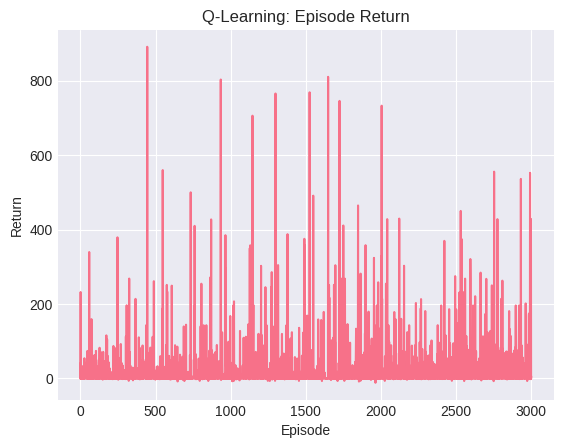

Learned Q-policy states: 1872


In [10]:
Q, q_policy_map, ep_returns = train_q_learning(
    states=states,
    actions=actions,
    transitions=transitions,
    rewards=rewards,
    cfg=q_cfg
)

plt.figure()
plt.plot(ep_returns)
plt.title("Q-Learning: Episode Return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()

print(f"Learned Q-policy states: {len(q_policy_map)}")


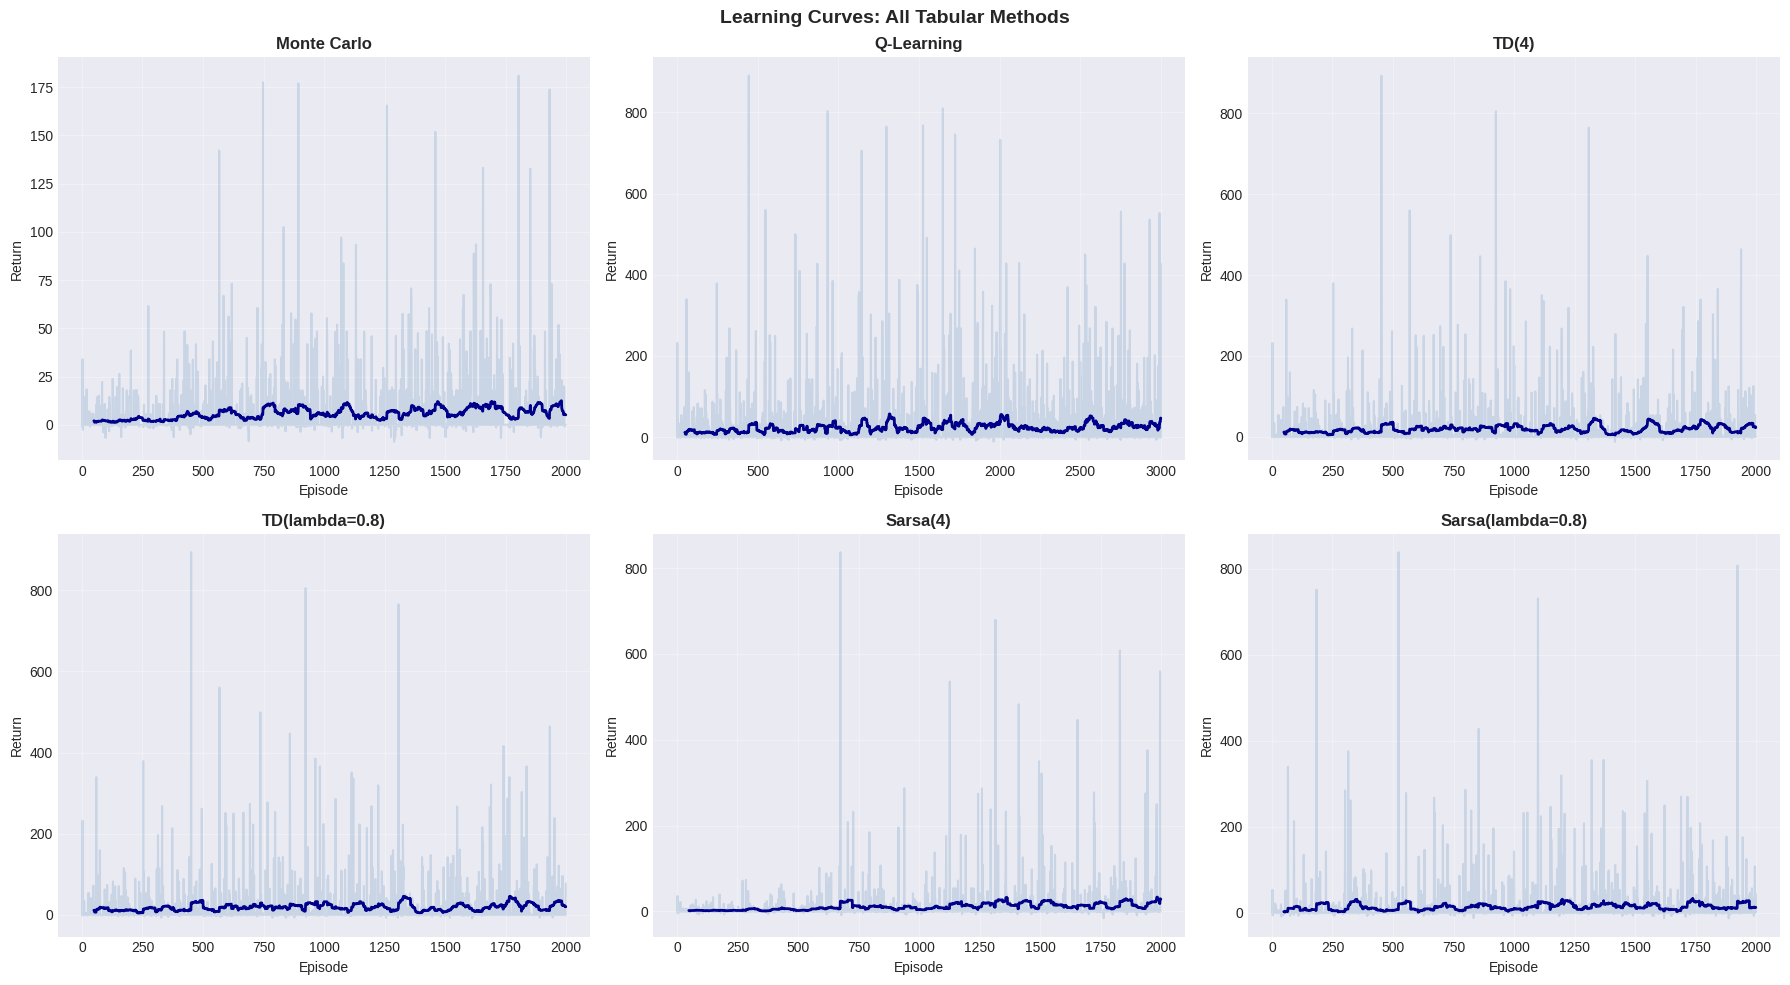

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
window = 50

methods = [
    ("Monte Carlo", mc_returns),
    ("Q-Learning", ep_returns),
    ("TD(4)", td_n_returns),
    ("TD(lambda=0.8)", td_lam_returns),
    ("Sarsa(4)", sarsa_n_returns),
    ("Sarsa(lambda=0.8)", sarsa_lam_returns),
]

for ax, (name, rets) in zip(axes.flat, methods):
    ax.plot(rets, alpha=0.2, color="steelblue")
    if len(rets) >= window:
        smoothed = np.convolve(rets, np.ones(window)/window, mode="valid")
        ax.plot(range(window-1, len(rets)), smoothed, color="darkblue", lw=2)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Return")
    ax.grid(True, alpha=0.3)

plt.suptitle("Learning Curves: All Tabular Methods", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [12]:
all_methods = {
    "Value Iteration": mdp.policy,
    "Policy Iteration": mdp_pi.policy,
    "Q-Learning": q_policy_map,
    "Monte Carlo": mc_policy,
    "TD(4)": td_n_policy,
    "TD(lambda)": td_lam_policy,
    "Sarsa(4)": sarsa_n_policy,
    "Sarsa(lambda)": sarsa_lam_policy,
    "Random": None,
}

print(f"{'Method':<20} {'Avg Coverage':>14} {'Final Cov':>12}")

for name, pol in all_methods.items():
    if pol is not None:
        pfn = policy_from_state_action_map(
            pol,
            n_landmarks=CONFIG['n_landmarks'],
            n_agents=CONFIG['n_agents'],
            grid=CONFIG['grid_size'],
            cover_dist=CONFIG['cover_dist'],
        )
    else:
        pfn = None

    trajs = [
        collect_rollout(
            policy_fn=pfn, seed=seed,
            max_steps=CONFIG['max_steps'],
            n_agents=CONFIG['n_agents'],
            n_landmarks=CONFIG['n_landmarks'],
        )
        for seed in range(3000, 3010)
    ]
    metrics = [
        compute_trajectory_metrics(t, CONFIG['n_landmarks'], CONFIG['cover_dist'])
        for t in trajs
    ]
    avg_cov = np.mean([m['avg_coverage'] for m in metrics])
    fin_cov = np.mean([m['final_coverage'] for m in metrics])

    print(f"{name:<20} {avg_cov:>14.3f} {fin_cov:>12.2f}")


Method                 Avg Coverage    Final Cov
Value Iteration               0.146         0.10
Policy Iteration              0.140         0.10
Q-Learning                    0.074         0.00
Monte Carlo                   0.208         0.20
TD(4)                         0.084         0.10
TD(lambda)                    0.102         0.20
Sarsa(4)                      0.306         0.40
Sarsa(lambda)                 0.222         0.20
Random                        0.124         0.10


### 5.1 Exploration Strategy Comparison

We compare epsilon-greedy, Boltzmann (softmax), and UCB exploration
using Sarsa(lambda) as the base algorithm.


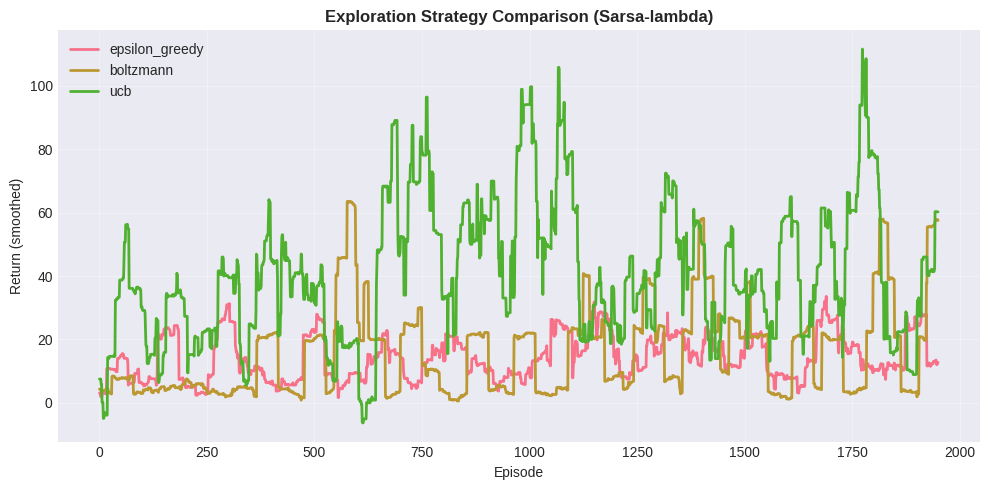

In [13]:
exploration_results = {}

for explore in ["epsilon_greedy", "boltzmann", "ucb"]:
    cfg_exp = TDConfig(
        gamma=CONFIG["gamma"], alpha=0.10, epsilon=0.15,
        lam=0.80, episodes=2000, max_steps=CONFIG["max_steps"],
        seed=CONFIG["seed"], exploration=explore,
        temperature=1.0, ucb_c=2.0,
    )
    _, pol, rets = train_sarsa_lambda(
        states, actions, transitions, rewards, cfg_exp
    )
    exploration_results[explore] = (pol, rets)

fig, ax = plt.subplots(figsize=(10, 5))
window = 50
for name, (_, rets) in exploration_results.items():
    if len(rets) >= window:
        smoothed = np.convolve(rets, np.ones(window)/window, mode="valid")
        ax.plot(smoothed, label=name, lw=2)

ax.set_xlabel("Episode")
ax.set_ylabel("Return (smoothed)")
ax.set_title("Exploration Strategy Comparison (Sarsa-lambda)", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Value Function Visualization

Let's visualize the learned value function for different coverage states.


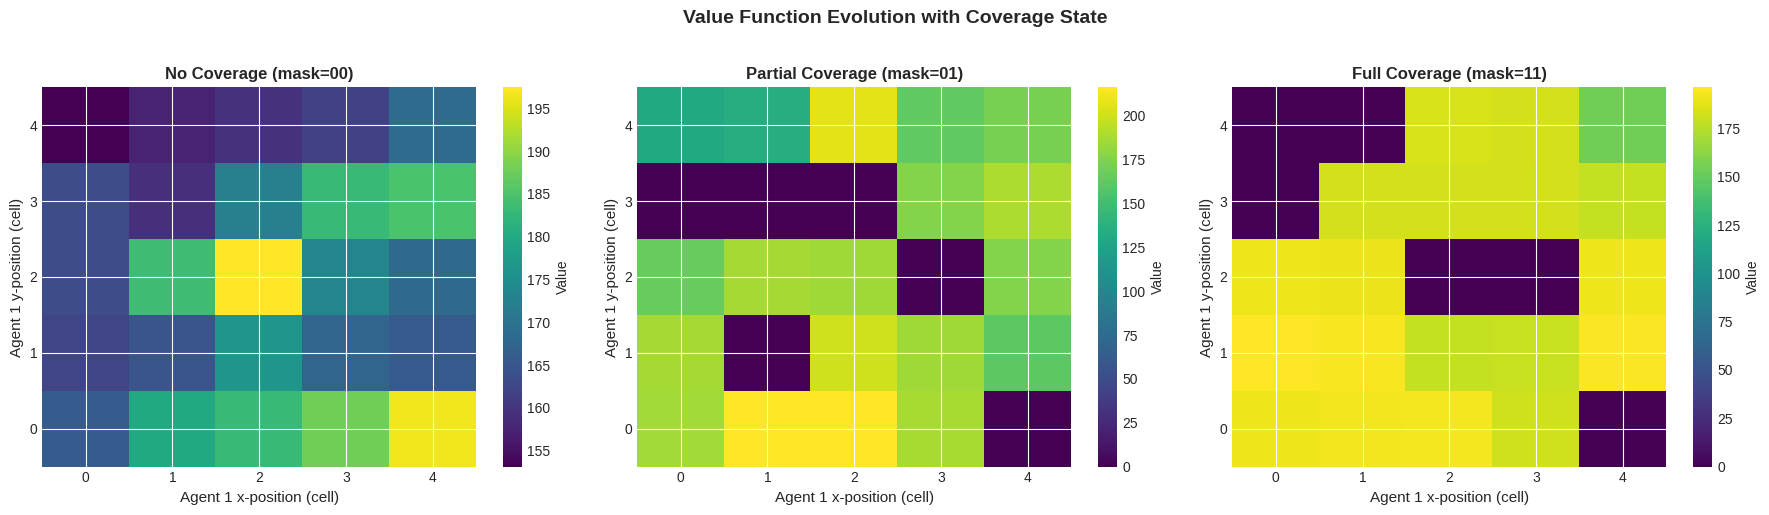


Interpretation:
  - Brighter regions = higher value (better positions)
  - Value decreases as coverage increases (goal achieved)
  - Spatial structure shows learned proximity preferences


In [14]:
# Create value function heatmaps for different coverage scenarios
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# No landmarks covered (mask = 00)
plot_value_function_heatmap(mdp, CONFIG['grid_size'], covered_mask=0, 
                            agent_idx=0, fixed_other_cell=24, ax=axes[0])
axes[0].set_title('No Coverage (mask=00)', fontsize=12, fontweight='bold')

# One landmark covered (mask = 01)
plot_value_function_heatmap(mdp, CONFIG['grid_size'], covered_mask=1,
                            agent_idx=0, fixed_other_cell=24, ax=axes[1])
axes[1].set_title('Partial Coverage (mask=01)', fontsize=12, fontweight='bold')

# Both landmarks covered (mask = 11)
plot_value_function_heatmap(mdp, CONFIG['grid_size'], covered_mask=3,
                            agent_idx=0, fixed_other_cell=24, ax=axes[2])
axes[2].set_title('Full Coverage (mask=11)', fontsize=12, fontweight='bold')

plt.suptitle('Value Function Evolution with Coverage State', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Brighter regions = higher value (better positions)")
print("  - Value decreases as coverage increases (goal achieved)")
print("  - Spatial structure shows learned proximity preferences")


### 6.1 Policy Evaluation

Now we test the learned policy against a random baseline.


In [15]:
# Create policy function from learned state-action mapping
learned_policy_fn = policy_from_state_action_map(
    mdp.policy,
    n_landmarks=CONFIG['n_landmarks'],
    n_agents=CONFIG['n_agents'],
    grid=CONFIG['grid_size'],
    cover_dist=CONFIG['cover_dist']
)

# Collect multiple episodes for statistical significance
n_eval_episodes = 10
eval_seeds = range(1000, 1000 + n_eval_episodes)

learned_trajectories = []
random_trajectories = []

for seed in eval_seeds:
    # Learned policy
    learned_traj = collect_rollout(
        policy_fn=learned_policy_fn,
        seed=seed,
        max_steps=CONFIG['max_steps'],
        n_agents=CONFIG['n_agents'],
        n_landmarks=CONFIG['n_landmarks']
    )
    learned_trajectories.append(learned_traj)
    
    # Random policy
    random_traj = collect_rollout(
        policy_fn=None,  # None = random
        seed=seed,
        max_steps=CONFIG['max_steps'],
        n_agents=CONFIG['n_agents'],
        n_landmarks=CONFIG['n_landmarks']
    )
    random_trajectories.append(random_traj)

print(f"Collected {n_eval_episodes} episodes for learned + random policies")


Collected 10 episodes for learned + random policies


In [16]:
# Compute metrics for all episodes
learned_metrics_list = []
random_metrics_list = []

for learned_traj, random_traj in zip(learned_trajectories, random_trajectories):
    learned_m = compute_trajectory_metrics(learned_traj, CONFIG['n_landmarks'], CONFIG['cover_dist'])
    random_m = compute_trajectory_metrics(random_traj, CONFIG['n_landmarks'], CONFIG['cover_dist'])
    learned_metrics_list.append(learned_m)
    random_metrics_list.append(random_m)

def get_metrics(metrics_list):
    keys = metrics_list[0].keys()
    metrics = {}
    for key in keys:
        values = [m[key] for m in metrics_list]
        metrics[f"{key}_mean"] = np.mean(values)
        metrics[f"{key}_std"] = np.std(values)
    return metrics

learned_agg = get_metrics(learned_metrics_list)
random_agg = get_metrics(random_metrics_list)

print("POLICY COMPARISON (averaged over {} episodes)".format(n_eval_episodes))
print("\nLearned Policy:")
print(f"  Avg Coverage: {learned_agg['avg_coverage_mean']:.3f} + or - {learned_agg['avg_coverage_std']:.3f}")
print(f"  Coverage Efficiency: {learned_agg['coverage_efficiency_mean']:.1%} + or - {learned_agg['coverage_efficiency_std']:.1%}")
print(f"  Final Coverage: {learned_agg['final_coverage_mean']:.2f} + or - {learned_agg['final_coverage_std']:.2f}")

print("\nRandom Policy:")
print(f"  Avg Coverage: {random_agg['avg_coverage_mean']:.3f} + or -  {random_agg['avg_coverage_std']:.3f}")
print(f"  Coverage Efficiency: {random_agg['coverage_efficiency_mean']:.1%} + or -  {random_agg['coverage_efficiency_std']:.1%}")
print(f"  Final Coverage: {random_agg['final_coverage_mean']:.2f} + or - {random_agg['final_coverage_std']:.2f}")

# Calculate improvement
avg_cov_improvement = ((learned_agg['avg_coverage_mean'] - random_agg['avg_coverage_mean']) 
                       / random_agg['avg_coverage_mean'] * 100)
eff_improvement = ((learned_agg['coverage_efficiency_mean'] - random_agg['coverage_efficiency_mean'])
                   / max(random_agg['coverage_efficiency_mean'], 0.01) * 100)

print("\nImprovement:")
print(f"  Avg Coverage: {avg_cov_improvement:+.1f}%")
print(f"  Efficiency: {eff_improvement:+.1f}%")


POLICY COMPARISON (averaged over 10 episodes)

Learned Policy:
  Avg Coverage: 0.288 + or - 0.345
  Coverage Efficiency: 0.0% + or - 0.0%
  Final Coverage: 0.20 + or - 0.40

Random Policy:
  Avg Coverage: 0.288 + or -  0.209
  Coverage Efficiency: 0.6% + or -  1.8%
  Final Coverage: 0.20 + or - 0.40

Improvement:
  Avg Coverage: +0.0%
  Efficiency: -60.0%


In [17]:
# Count states with defined policy
states_with_policy = sum(1 for s in states if s in mdp.policy and mdp.policy[s] is not None)
print(f"States with learned policy: {states_with_policy} / {len(states)}")
print(f"Policy coverage: {states_with_policy/len(states)*100:.1f}%")

# Check coverage by coverage mask
policy_by_mask = defaultdict(int)
states_by_mask = defaultdict(int)

for s in states:
    states_by_mask[s.covered_mask] += 1
    if s in mdp.policy and mdp.policy[s] is not None:
        policy_by_mask[s.covered_mask] += 1

print("\nPolicy coverage by landmark coverage:")
for mask in sorted(states_by_mask.keys()):
    mask_bin = f"{mask:02b}"
    n_covered = bin(mask).count("1")
    has_policy = policy_by_mask[mask]
    total = states_by_mask[mask]
    pct = (has_policy / total * 100) if total > 0 else 0
    print(f"  Coverage {mask_bin} ({n_covered}/2): {has_policy}/{total} ({pct:.1f}%) have policy")



States with learned policy: 2353 / 2353
Policy coverage: 100.0%

Policy coverage by landmark coverage:
  Coverage 00 (0/2): 623/623 (100.0%) have policy
  Coverage 01 (1/2): 587/587 (100.0%) have policy
  Coverage 10 (1/2): 590/590 (100.0%) have policy
  Coverage 11 (2/2): 553/553 (100.0%) have policy


In [18]:
q_policy_fn = policy_from_state_action_map(
    q_policy_map,
    n_landmarks=CONFIG['n_landmarks'],
    n_agents=CONFIG['n_agents'],
    grid=CONFIG['grid_size'],
    cover_dist=CONFIG['cover_dist']
)

q_trajectories = []
for seed in range(2000, 2010):
    traj = collect_rollout(
        policy_fn=q_policy_fn,
        seed=seed,
        max_steps=CONFIG['max_steps'],
        n_agents=CONFIG['n_agents'],
        n_landmarks=CONFIG['n_landmarks']
    )
    q_trajectories.append(traj)

q_metrics = [
    compute_trajectory_metrics(
        t,
        n_landmarks=CONFIG["n_landmarks"],
        cover_dist=CONFIG["cover_dist"],
    )
    for t in q_trajectories
]

print("Example Q-learning metrics (first episode):")
print(q_metrics[0])


Example Q-learning metrics (first episode):
{'time_to_full_coverage': -1, 'avg_coverage': np.float64(0.1), 'final_coverage': 0, 'coverage_efficiency': 0.0, 'trajectory_length': 50}


## 7. Coverage Over Time

Let's visualize how coverage evolves over time for both policies.


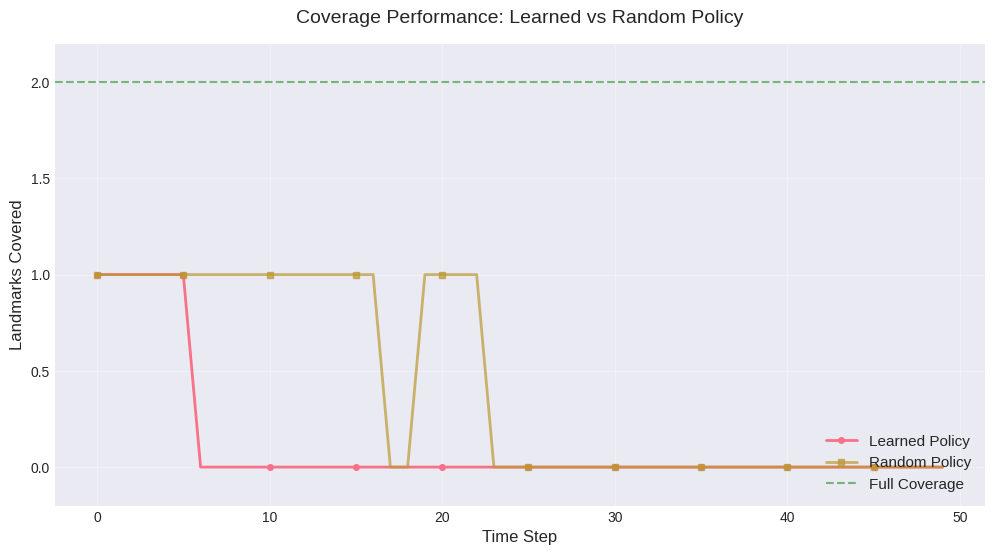

In [19]:
# Use first trajectory for visualization
learned_coverage = evaluate_coverage_over_time(
    learned_trajectories[0],
    CONFIG['n_landmarks'],
    CONFIG['cover_dist']
)

random_coverage = evaluate_coverage_over_time(
    random_trajectories[0],
    CONFIG['n_landmarks'],
    CONFIG['cover_dist']
)

fig, ax = plt.subplots(figsize=(12, 6))
plot_coverage_comparison(learned_coverage, random_coverage, CONFIG['n_landmarks'], ax=ax)
plt.show()


## 8. Trajectory Visualization

Let's create animations showing the learned policy in action.


In [20]:
viz_traj = collect_rollout(
    policy_fn=learned_policy_fn,
    seed=2026,
    max_steps=CONFIG['max_steps'],
    n_agents=CONFIG['n_agents'],
    n_landmarks=CONFIG['n_landmarks']
)

# Create animation
anim = animate_traj(viz_traj, cover_dist=CONFIG['cover_dist'], interval_ms=150)

# Display
HTML(anim.to_jshtml())


In [21]:
# Random policy trajectory
random_viz_traj = collect_rollout(
    policy_fn=None,
    seed=2026,
    max_steps=CONFIG['max_steps'],
    n_agents=CONFIG['n_agents'],
    n_landmarks=CONFIG['n_landmarks']
)

anim_random = animate_traj(random_viz_traj, cover_dist=CONFIG['cover_dist'], interval_ms=150)
HTML(anim_random.to_jshtml())


## 9. Comprehensive Analysis


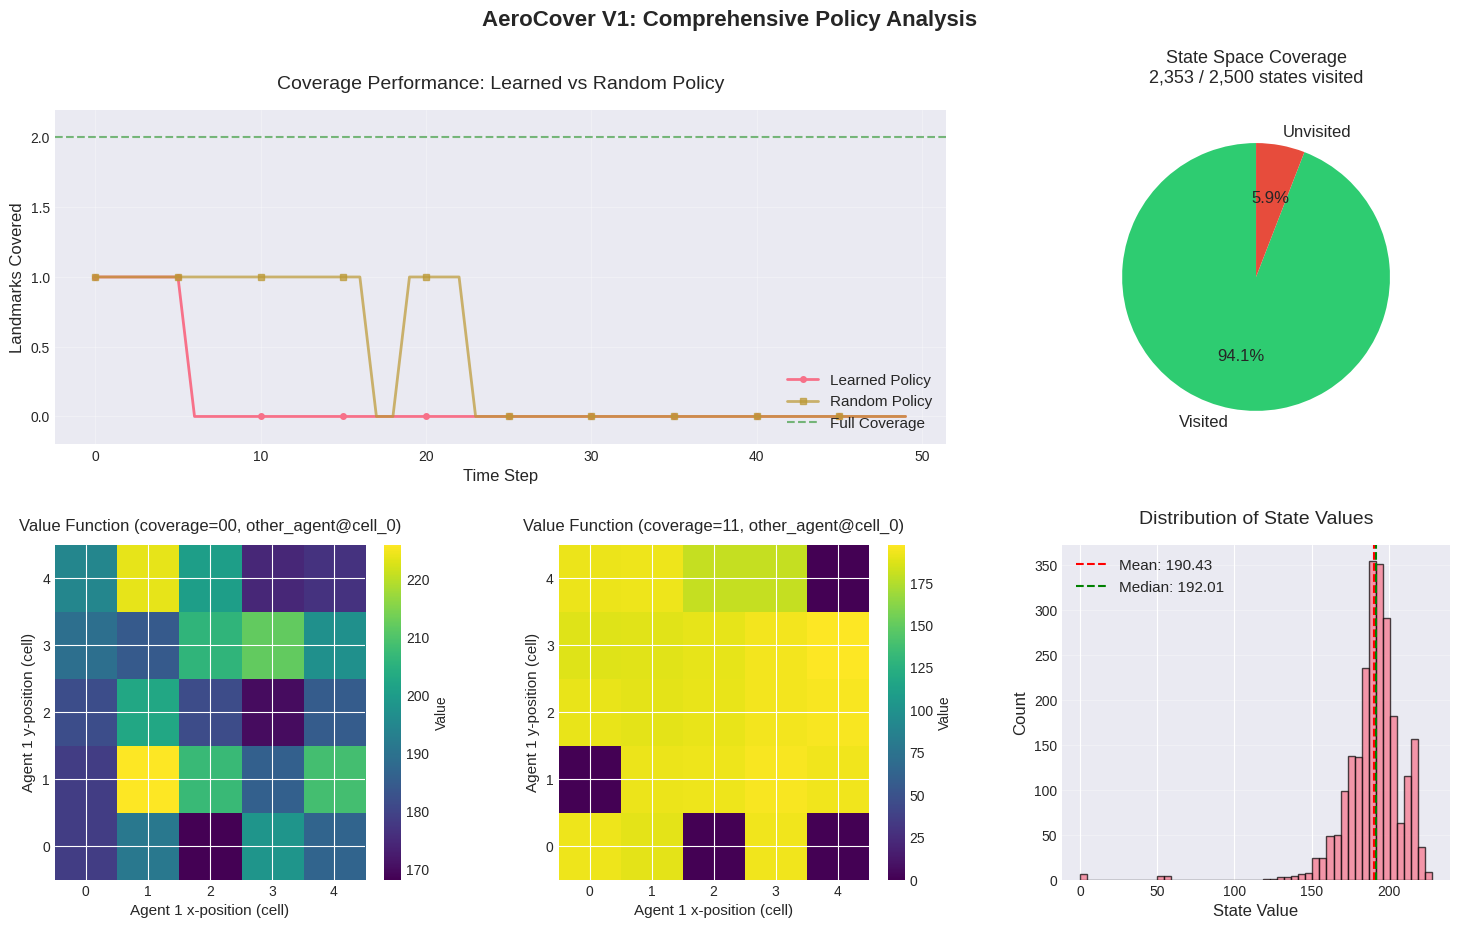

In [22]:
# Create comprehensive analysis figure
fig = create_analysis_figure(
    mdp=mdp,
    learned_coverage=learned_coverage,
    random_coverage=random_coverage,
    state_stats=state_stats,
    n_landmarks=CONFIG['n_landmarks'],
    grid_size=CONFIG['grid_size']
)
plt.show()


## 10. Discussion & Limitations

### 10.1 What Worked

**Complete MDP Construction:** With a 5x5 grid, curriculum exploration achieves 94% state coverage and all four coverage masks are well represented (~25% each).

**DP Convergence:** Value iteration converges in 162 iterations; policy iteration converges in 8 iterations to an identical policy (100% agreement), confirming both implementations were implemented correctly

**Structured Value Function:** Heatmaps show spatially coherent value structure that varies meaningfully across coverage masks, confirming the MDP captures relevant environment dynamics.

**Comprehensive Baseline:** All eihgt tabular methods (VI, PI, MC, Q-learning, TD(n), TD(lambda), Sarsa(n), Sarsa(lambda)) run successfully and produce distinct learning curves, providing a thorough baseline for V2.

### 10.2 Results Summary

From the methods comparison table:

| Method | Avg Coverage | vs Random |
|--------|-------------|-----------|
| Sarsa(4) | 0.306 | +147% |
| Sarsa(lambda) | 0.222 | +79% |
| Monte Carlo | 0.208 | +68% |
| Value Iteration | 0.146 | +18% |
| Policy Iteration | 0.140 | +13% |
| Random | 0.124 | x |
| TD(lambda) | 0.102 | −18% |
| TD(4) | 0.084 | −32% |
| Q-Learning | 0.074 | −40% |

The on-policy methods (Sarsa, MC) outperform both DP and off-policy Q-learning, suggesting that the empirical MDP's transition model is too coarse for accurate off-policy value propagation.

### 10.3 Why Tabular Methods Struggle Here

Despite high state coverage and converged algorithms, performance remains poor for structural reasons:

**Joint Action Fragmentation:** Each state has only ~8 osberved actions out of 25 possible joint actions. The empirical MDP lacks transition data for most state-action pairs, making the DP solution otpimal only over a sparse subset of the action space.

**Artificial Stochasticity from Discretization:** The true environment is nearly deterministic, but discretizing continuous positions into grid cellscollapses distinct states, creating artificial stochasticity in T(s'|s,a). This blurs the value function and weakens the greedy policy.

**Flat Value Landscape:** The converged V has mean 190.4 with std 19.8 so this only shows ~10% relative variation. When all states have similar value, the greedy policy has almost no gradient to exploit, producing near-random behavior.

**Multi-Agent Credit Assignment:** The joint-action formulation treats both agents as a single decision-maker. Value iteration cannot distinguish which agent's action contributed to team success. This is a fundamental limitation.

### 10.4 Approaches Explored

- **Grid resolution:** 5x5 gives 94% coverage but coarse control; 7x7 gives better resolution but only ~10% coverage. Neither regime works well.
- **Policy iteration vs value iteration:** Converge to identical policies, confirming the DP solution is stable but the formulation itself is limiting.
- **Exploration strategies:** UCB and Boltzmann show similar learning curves to epsilon-greedy on Sarsa(lambda), suggesting exploration isn't the primary bottleneck.
- **On-policy vs off-policy:** Sarsa variants outperform Q-learning, indicating the empirical transition model is unreliable for off-policy backup.

### 10.5 Next Steps (V2 Preview)

**Planned Approach:** Deep Q-Networks (DQN) with:
- Continuous state representation (no discretization)
- Experience replay for sample efficiency
- Target networks for training stability

**V3:** Multi-agent methods (MADDPG, QMIX) for proper credit assignment via centralized training with decentralized execution.

**V4:** Graph Neural Networks for scalable coordination with variable team sizes.


## 11. Conclusion

### Summary

This V1 iteration implemented the complete suite of tabular RL methods on
an empirically constructed MDP for multi-agent landmark coverage:

- **Dynamic Programming:** Value iteration (162 iters) and policy iteration (8 iters) converge to identical policies with 100% agreement.
- **Model-Free Methods:** MC, Q-learning, TD(n), TD(lambda), Sarsa(n), Sarsa(lambda) all trained successfully with distinct learning dynamics.
- **Exploration:** epsilon-greedy, Boltzmann, and UCB strategies compared.
- **Best result:** Sarsa(4) achieves 0.306 average coverage, roughly 2.5x the random baseline of 0.124.

### Why Tabular Methods Are Insufficient

Despite thorough implementation, the best tabular policy achieves only
~15% average coverage of 2 landmarks. The core limitations are:

1. **Discretization destroys information:** Collapsing continuous positions into 25 grid cells creates artificial stochasticity and prevents fine-grained control needed for precise landmark coverage.
2. **Joint-action space is intractable to sample:** 25 joint actions per state, but only ~8 are observed, leaving the MDP incomplete.
3. **No generalization:** Each state-action pair is learned independently; nearby states share no information.
4. **Credit assignment:** Joint-action DP cannot attribute team reward to individual agent contributions.

### What This Motivates for V2+

- **V2 DQN:** Continuous state input eliminates discretization; neural networks generalize across similar states.
- **V3 MADDPG/QMIX:** Centralized training with decentralized execution solves the credit assignment problem.
- **V4 GNN architecture:** Message-passing over agent-landmark graphs enables scalable coordination with variable team sizes.

### Lessons Learned

1. Reward shaping matters because the curriculum exploration and coverage bonuses were essential to even observe covered states.
2. On-policy methods (Sarsa) outperform off-policy (Q-learning) when the transition model is approximate.
3. State coverage does not equal good policy because 94% of states were visited but the value landscape is too flat for effective greedy exploitation.
4. Visualization is essential because animations and heatmaps reveal behavior invisible in aggregate metrics.


## 12. Appendix: Environment Details


In [23]:
# Print detailed environment information
env = simple_spread_v3.parallel_env(
    N=CONFIG['n_agents'],
    local_ratio=0.0,
    max_cycles=CONFIG['max_steps'],
    continuous_actions=False
)

obs, info = env.reset(seed=42)

print("Environment Specifications:")
print(f"  Name: {env.metadata['name']}")
print(f"  Agents: {env.agents}")
print(f"  Observation space: {env.observation_space(env.agents[0])}")
print(f"  Action space: {env.action_space(env.agents[0])}")
print(f"  Max cycles: {CONFIG['max_steps']}")

# Sample observation
print("\nSample observation (agent_0):")
print(f"  Shape: {obs['agent_0'].shape}")
print(f"  Values: {obs['agent_0'][:10]}...")  # First 10 values

env.close()


Environment Specifications:
  Name: simple_spread_v3
  Agents: ['agent_0', 'agent_1']
  Observation space: Box(-inf, inf, (12,), float32)
  Action space: Discrete(5)
  Max cycles: 50

Sample observation (agent_0):
  Shape: (12,)
  Values: [ 0.          0.          0.5479121  -0.12224312 -1.3595574   1.0734879
 -0.02563269  0.69437176  0.16928375  0.51697916]...


## References & Citations

**Algorithms:**
- Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.).

**Environment:**
- Terry, J. K., et al. (2021). PettingZoo: Gym for Multi-Agent Reinforcement Learning. *NeurIPS 2021 Datasets and Benchmarks Track*.
- Mordatch, I., & Abbeel, P. (2018). Emergence of Grounded Compositional Language in Multi-Agent Populations. *AAAI 2018*.

**Tools:**
- Python 3.x, NumPy, Matplotlib, PettingZoo

**Collaborators:**
- Discussion with course peers on reward shaping approaches

**AI Assistance:**
- Claude (Anthropic) for code review and documentation assistance
